In [28]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.sparse import csr_matrix, hstack as sp_hstack, save_npz, load_npz
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)

C = {
    'primary':  '#4361EE', 'secondary': '#3A0CA3', 'accent': '#F72585',
    'teal':     '#4CC9F0', 'green':     '#06D6A0', 'orange': '#FB8500',
    'yellow':   '#FFD166', 'red':       '#EF233C', 'purple': '#7209B7',
    'gray':     '#6C757D', 'light':     '#F8F9FA', 'dark':   '#1A1A2E',
}
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,    'axes.spines.right': False,
    'axes.grid': True,           'grid.alpha': 0.3,
    'font.size': 11,             'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
FIGURE_DPI = 130

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
CFG = {
    'drive_base': '/content/drive/MyDrive/CareerSegmentation',
    'n_parts': 6,

    'core_cols': [
        'LanguageHaveWorkedWith',
        'WebframeHaveWorkedWith',
        'DatabaseHaveWorkedWith',
        'PlatformHaveWorkedWith',
        'DevEnvsHaveWorkedWith',
    ],
    'supplement_col': 'AIModelsHaveWorkedWith',

    'col_prefix': {
        'LanguageHaveWorkedWith': 'lang',
        'WebframeHaveWorkedWith': 'wf',
        'DatabaseHaveWorkedWith': 'db',
        'PlatformHaveWorkedWith': 'plat',
        'DevEnvsHaveWorkedWith':  'env',
        'AIModelsHaveWorkedWith': 'ai',
    },

    # Detail tambahan untuk insight
    'meta_cols': [
        'ResponseId', 'DevType', 'EdLevel', 'YearsCode', 'WorkExp',
        'Country', 'ConvertedCompYearly', 'JobSat', 'RemoteWork',
        'Age', 'Employment', 'Industry',
    ],

    'primary_col': 'LanguageHaveWorkedWith',
    'max_missing_core': 2,

    # PCA/SVD
    'svd_n_components': 70, # Upperbound untuk mencari n_component dengan variance tertinggi

    # UMAP
    'umap_n_components':  15, # Agar tidak terjadi curse of dimensionality dan euclidean distance dapat digunakan
    'umap_n_neighbors':   20,
    'umap_min_dist':      0.05,
    'umap_metric':        'jaccard', # Agar ketidakpunyaan skillset antar developer tidak dianggap sebagai kesamaan
    'umap_random_state':  42,

    'out_dir': '/content/drive/MyDrive/CareerSegmentation/Outputs',
}

In [31]:
import os

CFG['dataset_dir']     = f"{CFG['drive_base']}/Dataset"
CFG['artifacts_dir']   = f"{CFG['out_dir']}/artifacts"
CFG['processed_dir']   = f"{CFG['out_dir']}/processed"

for d in [CFG['out_dir'], CFG['artifacts_dir'], CFG['processed_dir']]:
    os.makedirs(d, exist_ok=True)
    print(f"{d} made.")

/content/drive/MyDrive/CareerSegmentation/Outputs made.
/content/drive/MyDrive/CareerSegmentation/Outputs/artifacts made.
/content/drive/MyDrive/CareerSegmentation/Outputs/processed made.


# **Load Dataset**

In [32]:
def load_all_parts(cfg):
    parts = []
    for i in range(1, cfg['n_parts'] + 1):
        path = f"{cfg['dataset_dir']}/part_{i}_SO_survey.csv"
        try:
            df_p = pd.read_csv(path, low_memory=False)
            df_p['_part'] = i
            parts.append(df_p)
            print(f"  - part_{i}: {len(df_p):,} rows")
        except FileNotFoundError:
            print(f"  - part_{i}: NOT FOUND")
    df = pd.concat(parts, ignore_index=True)
    # Remove dupe
    df = df.drop_duplicates(subset='ResponseId', keep='first')
    print(f"\n  Total : {len(df):,} rows.")
    return df

df_raw = load_all_parts(CFG)

  - part_1: 8,117 rows
  - part_2: 8,163 rows
  - part_3: 8,182 rows
  - part_4: 8,156 rows
  - part_5: 8,243 rows
  - part_6: 8,330 rows

  Total : 49,191 rows.


# **Preprocessing**

Berdasarkan EDA yang telah dilakukan, fitur-fitur yang dipilih memiliki missing rate diatas 30% bahkan ada yang mencapai diatas 60%. Maka dari itu dipertimbangkan untuk drop row dengan:
1.   Drop jika LanguageHaveWorkedWith (Primary-Core Feature) tidak diisi
2.   Drop jika >= 2 Core Features tidak diisi



In [33]:
def drop_unusable_row(df, cfg, verbose=True):
    n0 = len(df)
    log = {'n_raw': n0}

    # 1. Drop jika LanguageHaveWorkedWith tidak diisi
    df = df[df[cfg['primary_col']].notna()].copy()
    log['after_primary_drop'] = len(df)
    if verbose:
        print(f"1. Drop null '{cfg['primary_col']}' : "
              f"{n0:,} → {len(df):,} (dropped {n0-len(df):,})")

    # 2. Drop jika >= 2 non-primary core feature tidak diisi
    other_core = [c for c in cfg['core_cols'] if c != cfg['primary_col']]
    df['missing_core'] = df[other_core].isna().sum(axis=1)

    df = df[df['missing_core'] < cfg['max_missing_core']].copy()
    df.drop(columns=['missing_core'], inplace=True)
    log['after_missing_drop'] = len(df)

    if verbose:
        total_drop = n0 - len(df)
        print(f"2. Drop >={cfg['max_missing_core']} missing core : "
              f"{log['after_primary_drop']:,} → {len(df):,} "
              f"(dropped {log['after_primary_drop']-len(df):,})")
        print(f"\n After drop : {len(df):,} rows retained "
              f"({len(df)/n0*100:.1f}% of raw)")

    return df, log

df_clean, drop_log = drop_unusable_row(df_raw, CFG)

1. Drop null 'LanguageHaveWorkedWith' : 49,191 → 31,671 (dropped 17,520)
2. Drop >=2 missing core : 31,671 → 23,387 (dropped 8,284)

 After drop : 23,387 rows retained (47.5% of raw)


Metadata (detail untuk insight) dipisahkan dari feature matrix

In [34]:
def split_meta(df, cfg):
    metadata = [c for c in cfg['meta_cols'] if c in df.columns]

    df_meta = df[['ResponseId'] + [c for c in metadata if c != 'ResponseId']].copy()
    df_core  = df[['ResponseId'] + cfg['core_cols'] + [cfg['supplement_col']]].copy()

    print(f"  - Metadata columns : {len(df_meta.columns)}")
    print(f"  - Core columns     : {len(df_core.columns)}")

    return df_core, df_meta

df_core, df_meta = split_meta(df_clean, CFG)

  - Metadata columns : 12
  - Core columns     : 7


# **Feature Extraction**

Fitur masih berupa kateogirkal sehingga perlu diencode menggunakan Multi-hot Binary Encoding

In [35]:
def parse_multi(series, sep=';'):
    result = []
    for v in series:
        if pd.isna(v):
            result.append([])
        else:
            result.append([x.strip() for x in str(v).split(sep) if x.strip()])
    return result

def multihot_encoding(df_core, cfg, save_dir=None):
    all_matrices    = []
    all_feat_names  = []
    encoders        = {}
    col_feature_map = {}

    all_cols = cfg['core_cols'] + [cfg['supplement_col']]

    print("Encoding columns:")
    for col in all_cols:
        parsed = parse_multi(df_core[col])
        mlb = MultiLabelBinarizer(sparse_output=False)
        X_col = mlb.fit_transform(parsed).astype(np.int8)
        encoders[col] = mlb

        prefix = cfg['col_prefix'][col]
        feat_names = [f"{prefix}__{cls}" for cls in mlb.classes_]
        col_feature_map[col] = feat_names

        all_matrices.append(X_col)
        all_feat_names.extend(feat_names)

        print(f"  - {col:<25s} : {X_col.shape[1]:3d} features ")

    X_binary = np.hstack(all_matrices).astype(np.int8)

    print(f"\nBinary matrix shape : {X_binary.shape}")
    print(f"Total features          : {len(all_feat_names)}")


    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        # Save encoders
        joblib.dump(encoders, f"{save_dir}/mlb_encoders.pkl")
        # Save feature names
        with open(f"{save_dir}/feature_names.json", 'w') as f:
            json.dump(all_feat_names, f, indent=2)
        # Save col_feature_map
        with open(f"{save_dir}/col_feature_map.json", 'w') as f:
            json.dump(col_feature_map, f, indent=2)

    return X_binary, all_feat_names, encoders, col_feature_map

X_binary, feature_names, encoders, col_feature_map = multihot_encoding(
    df_core, CFG, save_dir=CFG['artifacts_dir']
)

Encoding columns:
  - LanguageHaveWorkedWith    :  42 features 
  - WebframeHaveWorkedWith    :  28 features 
  - DatabaseHaveWorkedWith    :  30 features 
  - PlatformHaveWorkedWith    :  42 features 
  - DevEnvsHaveWorkedWith     :  27 features 
  - AIModelsHaveWorkedWith    :  17 features 

Binary matrix shape : (23387, 186)
Total features          : 186


In [36]:
def save_preocessed(X_binary, df_core, df_meta, feature_names, cfg):
    out = cfg['processed_dir']
    os.makedirs(out, exist_ok=True)
    print(f"Artifacts saved to {CFG['processed_dir']}:")

    # 1. Sparse matrix
    X_sparse = csr_matrix(X_binary)
    npz_path = f"{out}/X_binary.npz"
    save_npz(npz_path, X_sparse)
    npz_size  = os.path.getsize(npz_path) / 1024
    print(f"  - X_binary.npz")

    # 2. ResponseId order (row index alignment)
    resp_ids = df_core['ResponseId'].values
    np.save(f"{out}/respondent_ids.npy", resp_ids)
    print(f"  - respondent_ids.npy")

    # 3. Metadata CSV
    meta_path = f"{out}/df_meta_clean.csv"
    df_meta.to_csv(meta_path, index=False)
    print(f"  - df_meta_clean.csv")

    # 4. Feature names list
    feat_path = f"{cfg['artifacts_dir']}/feature_names.json"
    with open(feat_path, 'w') as f:
        json.dump(feature_names, f, indent=2)
    print(f"  - feature_names.json")

    # 5. Dense CSV
    feat_df = pd.DataFrame(X_binary, columns=feature_names)
    feat_df.insert(0, 'ResponseId', resp_ids)
    csv_path = f"{out}/X_binary_with_id.csv"
    feat_df.to_csv(csv_path, index=False)
    csv_size  = os.path.getsize(csv_path) / 1024 / 1024
    print(f"  - X_binary_with_id.csv")

    return X_sparse

X_sparse = save_preocessed(X_binary, df_core, df_meta, feature_names, CFG)

Artifacts saved to /content/drive/MyDrive/CareerSegmentation/Outputs/processed:
  - X_binary.npz
  - respondent_ids.npy
  - df_meta_clean.csv
  - feature_names.json
  - X_binary_with_id.csv


# **Dimensionality Reduction**

## SVD

In [37]:
def svd(X_sparse, cfg, save_dir=None):
    n_comp = cfg['svd_n_components']
    print(f"Fitting TruncatedSVD with n_components={n_comp}.")

    svd = TruncatedSVD(n_components=n_comp, algorithm='randomized',
                       n_iter=7, random_state=42)
    X_svd = svd.fit_transform(X_sparse)

    cum_var = np.cumsum(svd.explained_variance_ratio_) * 100

    print(f"Shape : {X_svd.shape}")
    print(f"Variance explained (70 components) : {cum_var[69]:.1f}%")

    if save_dir:
        np.save(f"{save_dir}/X_svd.npy", X_svd)
        joblib.dump(svd, f"{save_dir}/svd_model.pkl")
        print(f"  - X_svd.npy ({X_svd.shape}) saved")
        print(f"  - svd_model.pkl saved")

    return X_svd, svd, cum_var

X_svd, svd_model, cum_var_svd = svd(X_sparse, CFG, save_dir=CFG['processed_dir'])

joblib.dump(svd_model, f"{CFG['artifacts_dir']}/svd_model.pkl")

Fitting TruncatedSVD with n_components=70.
Shape : (23387, 70)
Variance explained (70 components) : 77.0%
  - X_svd.npy ((23387, 70)) saved
  - svd_model.pkl saved


['/content/drive/MyDrive/CareerSegmentation/Outputs/artifacts/svd_model.pkl']

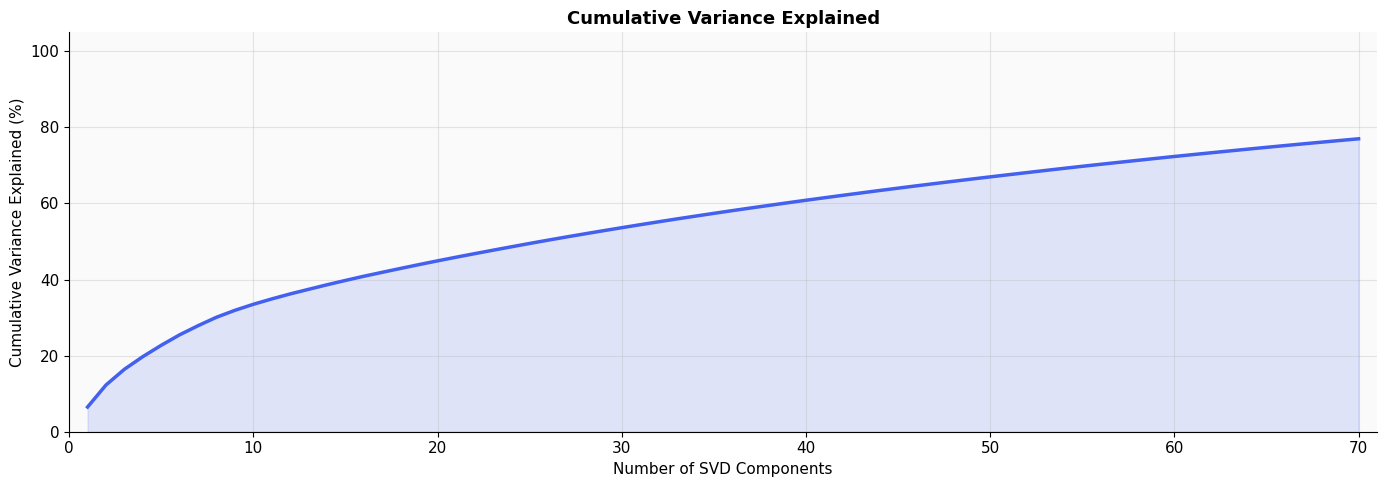

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Cumulative Variance
ax = axes
comp_range = range(1, len(cum_var_svd) + 1)
ax.plot(comp_range, cum_var_svd, color=C['primary'], lw=2.5)
ax.fill_between(comp_range, cum_var_svd, alpha=0.15, color=C['primary'])

ax.set_xlabel('Number of SVD Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('Cumulative Variance Explained')
ax.set_ylim(0, 105)
ax.set_xlim(0, len(cum_var_svd) + 1)

plt.tight_layout()
plt.show()

Dapat dilihat bahwa pertumbuhan variance explained SVD mulai mendatar setelah 10 components, bahkan membutuhkan 70 component untuk mencapai 77% variance. Ini belum menyelesaikan masalah curse of dimensionality sepenuhnya.

## UMAP

In [39]:
def umap(X_binary, cfg, save_dir=None):
    import umap

    print(" Fitting UMAP:")
    print(f"  - n_components  : {cfg['umap_n_components']}")
    print(f"  - n_neighbors   : {cfg['umap_n_neighbors']}")
    print(f"  - min_dist      : {cfg['umap_min_dist']}")
    print(f"  - metric        : {cfg['umap_metric']}")

    X_dense = X_binary.astype(np.float32)

    reducer = umap.UMAP(
        n_components   = cfg['umap_n_components'],
        n_neighbors    = cfg['umap_n_neighbors'],
        min_dist       = cfg['umap_min_dist'],
        metric         = cfg['umap_metric'],
        random_state   = cfg['umap_random_state'],
        low_memory     = True,
        verbose        = True,
    )
    X_umap = reducer.fit_transform(X_dense)

    print(f"\nUMAP shape: {X_umap.shape}")

    if save_dir:
        np.save(f"{save_dir}/X_umap.npy", X_umap)
        joblib.dump(reducer, f"{save_dir}/umap_model.pkl")
        print(f"  - X_umap.npy saved")
        print(f"  - umap_model.pkl saved")

        joblib.dump(reducer, f"{cfg['artifacts_dir']}/umap_model.pkl")

    return X_umap, reducer

X_umap, umap_model = umap(X_binary, CFG, save_dir=CFG['processed_dir'])

 Fitting UMAP:
  - n_components  : 15
  - n_neighbors   : 20
  - min_dist      : 0.05
  - metric        : jaccard
UMAP(angular_rp_forest=True, metric='jaccard', min_dist=0.05, n_components=15, n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Tue Jun 16 16:17:59 2026 Construct fuzzy simplicial set
Tue Jun 16 16:17:59 2026 Finding Nearest Neighbors
Tue Jun 16 16:17:59 2026 Building RP forest with 13 trees
Tue Jun 16 16:17:59 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Tue Jun 16 16:18:07 2026 Finished Nearest Neighbor Search
Tue Jun 16 16:18:07 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Jun 16 16:18:49 2026 Finished embedding

UMAP shape: (23387, 15)
Tue Jun 16 16:18:49 2026 Building hub-based search tree
Tue Jun 16 16:18:50 2026 Forward diversification reduced edges from 467740 to 222903
Tue Jun 16 16:18:50 2026 Reverse diversification reduced edges from 222903 to 222464
Tue Jun 16 16:18:50 2026 Degree pruning reduced edges from 286248 to 283978
Tue Jun 16 16:18:50 2026 Resorting data and graph based on tree order
Tue Jun 16 16:18:50 2026 Building and compiling search function
  - X_umap.npy saved
  - umap_model.pkl saved


UMAP dapat menekan dimensi hingga 15 komponen sehingga euclidean distance lebih cocok digunakan disini.